<div style='text-align: center; padding: 30px'>
  <h1><strong>Returns</strong></h1>
  <h3><strong>Heriberto Espino Montelongo</strong></h1>
</div>

In [1]:
import joypy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file = r'cryptos-index.csv'
data = pd.read_csv(file, index_col="Date", parse_dates=True)

# **Ultimos 3 years**

In [3]:
returns = data.pct_change().dropna()            # Calculate returns

In [4]:
returns

,BTC,ETH,BNB,XRP,ADA,SOL,DOGE,TRX,TON,MATIC,...,DAI,LINK,LEO,XLM,WSTETH,HBAR,SHIB,BCH,EWP,PP
Date,,,,,,,,,,,,,,,,,,,,,
2021-10-08 00:00:00+00:00,0.003008,-0.006749,-0.044807,-0.004808,-0.017488,0.030257,0.003820,0.022573,0.065562,0.052894,...,-0.000322,-0.016139,-0.040948,-0.024106,-0.011616,-0.011365,0.173913,-0.026765,0.000929,0.002887
2021-10-09 00:00:00+00:00,0.018536,0.003355,0.005840,0.091294,0.013159,-0.013359,0.011257,0.053241,0.048309,0.005292,...,0.000956,0.038488,0.020838,0.050793,0.004265,-0.007361,0.000000,0.031406,0.016825,0.018403
2021-10-10 00:00:00+00:00,-0.003577,-0.041912,-0.039094,-0.018512,-0.030619,-0.055967,-0.068091,-0.049791,-0.066657,-0.076206,...,-0.000567,-0.064490,-0.024395,-0.057676,-0.030452,-0.073877,-0.037037,-0.045308,-0.008252,-0.003877
2021-10-11 00:00:00+00:00,0.049537,0.034882,0.020705,-0.000496,-0.010843,-0.021551,0.007389,-0.005995,-0.054655,-0.003566,...,0.000204,-0.015210,-0.009459,0.036206,0.008961,0.000774,0.192308,0.025856,0.045629,0.049284
2021-10-12 00:00:00+00:00,-0.025115,-0.014887,0.073554,-0.031663,-0.024938,0.054391,-0.022725,-0.017013,-0.031440,-0.015963,...,-0.000404,-0.025146,0.022236,-0.033130,-0.008392,0.018919,-0.064516,-0.023864,-0.022836,-0.024993
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-10 00:00:00+00:00,-0.025670,-0.076585,-0.040496,-0.054475,-0.066031,-0.064410,-0.081900,-0.010444,-0.858370,-0.060629,...,0.000149,-0.078432,0.001391,-0.077883,-0.067245,-0.049350,0.000000,-0.071616,-0.028444,-0.025845
2025-03-11 00:00:00+00:00,0.055139,0.031536,0.036369,0.073637,0.074324,0.058941,0.065598,-0.022049,0.307049,0.040876,...,-0.000042,0.032044,0.013864,0.052509,0.026613,0.033637,0.000000,0.023659,0.053581,0.055043
2025-03-12 00:00:00+00:00,0.010380,-0.005658,0.033402,0.034076,0.017793,0.010532,0.050041,-0.006376,-0.159987,0.004242,...,0.000005,0.029198,-0.017567,0.017896,-0.012436,0.026317,0.000000,0.042611,0.009718,0.010314


In [5]:
returns = returns.drop(columns='DAI')           # drop DAI, its too stable

In [6]:
returns = returns.drop(columns='TON')           # drop DAI, its too stable

In [7]:
returns_std = returns.std().sort_values().index # order them by the standard deviation
returns = returns[returns_std]                  # change the order of the columns

In [8]:
# Calculate the variance of returns
returns_std = returns.std()

# Create a color palette based on the variance
cmap = sns.color_palette("Blues_r", as_cmap=True)
colors = [cmap(v) for v in (returns_std - returns_std.min()) / (returns_std.max() - returns_std.min())]

In [9]:
# change the name of the columns to add the mean and the std
returns.columns = [f"{c} μ={returns[c].mean():.4f}, σ={returns[c].std():.4f}" for c in returns.columns]

c:\Users\herie\.conda\envs\data-mining\Lib\site-packages\joypy\joyplot.py:435: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  fig, axes = _subplots(naxes=num_axes, ax=ax, squeeze=False,


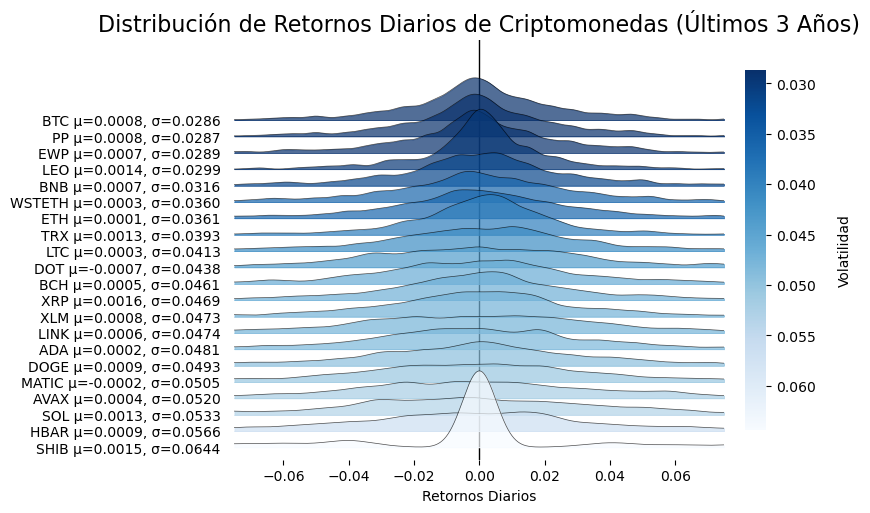

In [10]:
# Ajustar el tamaño de la figura para acomodar el título y la barra de color
fig, ax = plt.subplots(figsize=(7, 6))  # Aumenta el tamaño de la figura

# Plot the joyplot with the new colors
joypy.joyplot(returns, overlap=1.5, fade=False, ax=ax, x_range=(-0.075, 0.075), color=colors, bw_method=0.08, linewidth=0.5, alpha=0.7)

# Adjust the font size of the y-axis tick labels
ax.tick_params(axis='y', labelsize=1)  # Set the desired font size

plt.axvline(x=0, color='k', linewidth=1)
plt.title('Distribución de Retornos Diarios de Criptomonedas (Últimos 3 Años)', fontsize=16)
plt.xlabel('Retornos Diarios')

# Add mean and std as text next to each distribution
for i, column in enumerate(returns.columns):
    mean = returns[column].mean()
    std = returns[column].std()
    ax.text(0.08, i, f"μ={mean:.4f}\nσ={std:.4f}", fontsize=10, va='center', ha='left', color='black')

# Add color bar to the right
norm = plt.Normalize(vmin=returns_std.min(), vmax=returns_std.max())
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Create a new axis for the color bar
cbar_ax = fig.add_axes([0.88, 0.2, 0.03, 0.6])  # Ajusta la posición de la barra de color
cbar = plt.colorbar(sm, cax=cbar_ax, label='\nVolatilidad', orientation='vertical')
cbar.ax.yaxis.set_label_position('right')
cbar.ax.yaxis.set_ticks_position('right')

# Invert the color bar axis
cbar.ax.invert_yaxis()

# Remove the dark lines from the color bar
cbar.outline.set_edgecolor('none')

# Ajustar los márgenes manualmente para evitar que se corte la imagen
plt.subplots_adjust(left=0.15, right=0.85, top=0.85, bottom=0.15)

# Guardar la figura como SVG
plt.savefig('svg/05-cryptos-joyplot-3y.svg', format='svg', bbox_inches='tight')  # bbox_inches='tight' asegura que todo se guarde
plt.show()

c:\Users\herie\.conda\envs\data-mining\Lib\site-packages\joypy\joyplot.py:435: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  fig, axes = _subplots(naxes=num_axes, ax=ax, squeeze=False,


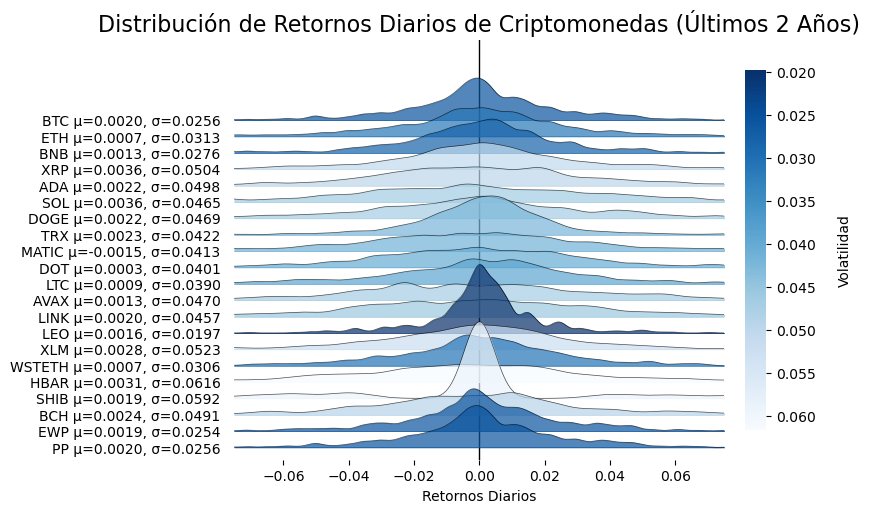

In [11]:
returns = data.pct_change().dropna()            # Calculate returns

# keep from the last 2 years
returns = returns['2023-03-14':]

returns = returns.drop(columns='DAI')           # drop DAI, its too stable
returns = returns.drop(columns='TON')           # drop DAI, its too stable

returns_std = returns.std()

# Create a color palette based on the variance
cmap = sns.color_palette("Blues_r", as_cmap=True)
colors = [cmap(v) for v in (returns_std - returns_std.min()) / (returns_std.max() - returns_std.min())]

# change the name of the columns to add the mean and the std
returns.columns = [f"{c} μ={returns[c].mean():.4f}, σ={returns[c].std():.4f}" for c in returns.columns]

# Ajustar el tamaño de la figura para acomodar el título y la barra de color
fig, ax = plt.subplots(figsize=(7, 6))  # Aumenta el tamaño de la figura

# Plot the joyplot with the new colors
joypy.joyplot(returns, overlap=1.5, fade=False, ax=ax, x_range=(-0.075, 0.075), color=colors, bw_method=0.08, linewidth=0.5, alpha=0.7)
plt.axvline(x=0, color='k', linewidth=1)
plt.title('Distribución de Retornos Diarios de Criptomonedas (Últimos 2 Años)', fontsize=16)
plt.xlabel('Retornos Diarios')

# Add color bar to the right
norm = plt.Normalize(vmin=returns_std.min(), vmax=returns_std.max())
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Create a new axis for the color bar
cbar_ax = fig.add_axes([0.88, 0.2, 0.03, 0.6])  # Ajusta la posición de la barra de color
cbar = plt.colorbar(sm, cax=cbar_ax, label='\nVolatilidad', orientation='vertical')
cbar.ax.yaxis.set_label_position('right')
cbar.ax.yaxis.set_ticks_position('right')

# Invert the color bar axis
cbar.ax.invert_yaxis()

# Remove the dark lines from the color bar
cbar.outline.set_edgecolor('none')

# Ajustar los márgenes manualmente para evitar que se corte la imagen
plt.subplots_adjust(left=0.15, right=0.85, top=0.85, bottom=0.15)

# Guardar la figura como SVG
plt.savefig('svg/05-cryptos-joyplot-2y.svg', format='svg', bbox_inches='tight')  # bbox_inches='tight' asegura que todo se guarde
plt.show()

c:\Users\herie\.conda\envs\data-mining\Lib\site-packages\joypy\joyplot.py:435: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  fig, axes = _subplots(naxes=num_axes, ax=ax, squeeze=False,


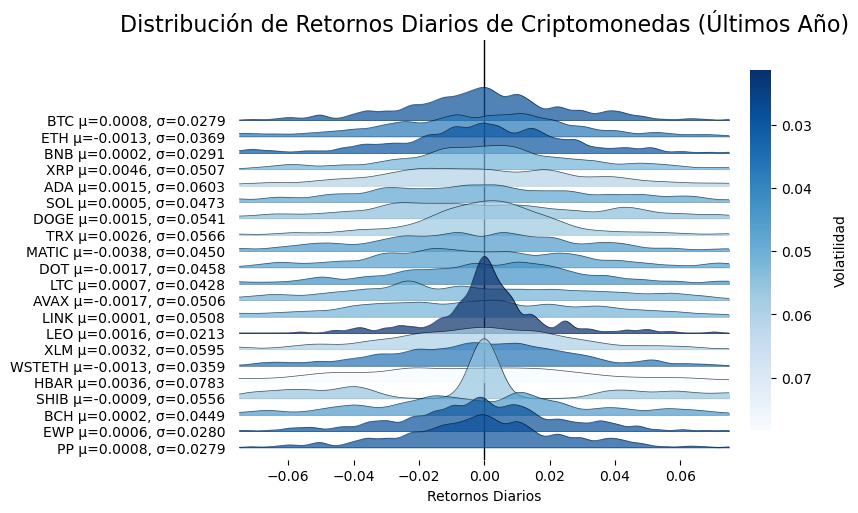

In [12]:
returns = data.pct_change().dropna()            # Calculate returns

# keep from the last 2 years
returns = returns['2024-03-14':]

returns = returns.drop(columns='DAI')           # drop DAI, its too stable
returns = returns.drop(columns='TON')           # drop DAI, its too stable

returns_std = returns.std()

# change the name of the columns to add the mean and the std
returns.columns = [f"{c} μ={returns[c].mean():.4f}, σ={returns[c].std():.4f}" for c in returns.columns]

# Create a color palette based on the variance
cmap = sns.color_palette("Blues_r", as_cmap=True)
colors = [cmap(v) for v in (returns_std - returns_std.min()) / (returns_std.max() - returns_std.min())]

# Ajustar el tamaño de la figura para acomodar el título y la barra de color
fig, ax = plt.subplots(figsize=(7, 6))  # Aumenta el tamaño de la figura

# Plot the joyplot with the new colors
joypy.joyplot(returns, overlap=1.5, fade=False, ax=ax, x_range=(-0.075, 0.075), color=colors, bw_method=0.08, linewidth=0.5, alpha=0.7)
plt.axvline(x=0, color='k', linewidth=1)
plt.title('Distribución de Retornos Diarios de Criptomonedas (Últimos Año)', fontsize=16)
plt.xlabel('Retornos Diarios')

# Add color bar to the right
norm = plt.Normalize(vmin=returns_std.min(), vmax=returns_std.max())
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Create a new axis for the color bar
cbar_ax = fig.add_axes([0.88, 0.2, 0.03, 0.6])  # Ajusta la posición de la barra de color
cbar = plt.colorbar(sm, cax=cbar_ax, label='\nVolatilidad', orientation='vertical')
cbar.ax.yaxis.set_label_position('right')
cbar.ax.yaxis.set_ticks_position('right')

# Invert the color bar axis
cbar.ax.invert_yaxis()

# Remove the dark lines from the color bar
cbar.outline.set_edgecolor('none')

# Ajustar los márgenes manualmente para evitar que se corte la imagen
plt.subplots_adjust(left=0.15, right=0.85, top=0.85, bottom=0.15)

# Guardar la figura como SVG
plt.savefig('svg/05-cryptos-joyplot-1y.svg', format='svg', bbox_inches='tight')  # bbox_inches='tight' asegura que todo se guarde
plt.show()

c:\Users\herie\.conda\envs\data-mining\Lib\site-packages\joypy\joyplot.py:435: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  fig, axes = _subplots(naxes=num_axes, ax=ax, squeeze=False,


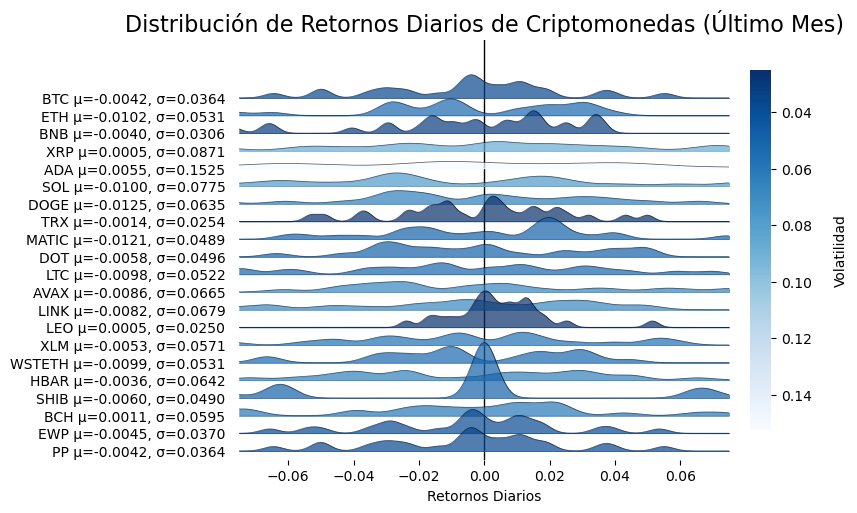

In [13]:
returns = data.pct_change().dropna()            # Calculate returns

# keep from the last 2 years
returns = returns['2025-02-14':]

returns = returns.drop(columns='DAI')           # drop DAI, its too stable
returns = returns.drop(columns='TON')           # drop DAI, its too stable

returns_std = returns.std()

# change the name of the columns to add the mean and the std
returns.columns = [f"{c} μ={returns[c].mean():.4f}, σ={returns[c].std():.4f}" for c in returns.columns]

# Create a color palette based on the variance
cmap = sns.color_palette("Blues_r", as_cmap=True)
colors = [cmap(v) for v in (returns_std - returns_std.min()) / (returns_std.max() - returns_std.min())]

# Ajustar el tamaño de la figura para acomodar el título y la barra de color
fig, ax = plt.subplots(figsize=(7, 6))  # Aumenta el tamaño de la figura

# Plot the joyplot with the new colors
joypy.joyplot(returns, overlap=1, fade=False, ax=ax, x_range=(-0.075, 0.075), color=colors, bw_method=0.08, linewidth=0.5, alpha=0.7)
plt.axvline(x=0, color='k', linewidth=1)
plt.title('Distribución de Retornos Diarios de Criptomonedas (Último Mes)', fontsize=16)
plt.xlabel('Retornos Diarios')

# Add color bar to the right
norm = plt.Normalize(vmin=returns_std.min(), vmax=returns_std.max())
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Create a new axis for the color bar
cbar_ax = fig.add_axes([0.88, 0.2, 0.03, 0.6])  # Ajusta la posición de la barra de color
cbar = plt.colorbar(sm, cax=cbar_ax, label='\nVolatilidad', orientation='vertical')
cbar.ax.yaxis.set_label_position('right')
cbar.ax.yaxis.set_ticks_position('right')

# Invert the color bar axis
cbar.ax.invert_yaxis()

# Remove the dark lines from the color bar
cbar.outline.set_edgecolor('none')

# Ajustar los márgenes manualmente para evitar que se corte la imagen
plt.subplots_adjust(left=0.15, right=0.85, top=0.85, bottom=0.15)

# Guardar la figura como SVG
plt.savefig('svg/05-cryptos-joyplot-1m.svg', format='svg', bbox_inches='tight')  # bbox_inches='tight' asegura que todo se guarde
plt.show()

C:\Users\herie\AppData\Local\Temp\ipykernel_2656\3370106626.py:47: DeprecationWarning: Pickle, copy, and deepcopy support will be removed from itertools in Python 3.14.
  pickle.dump(fig, f)


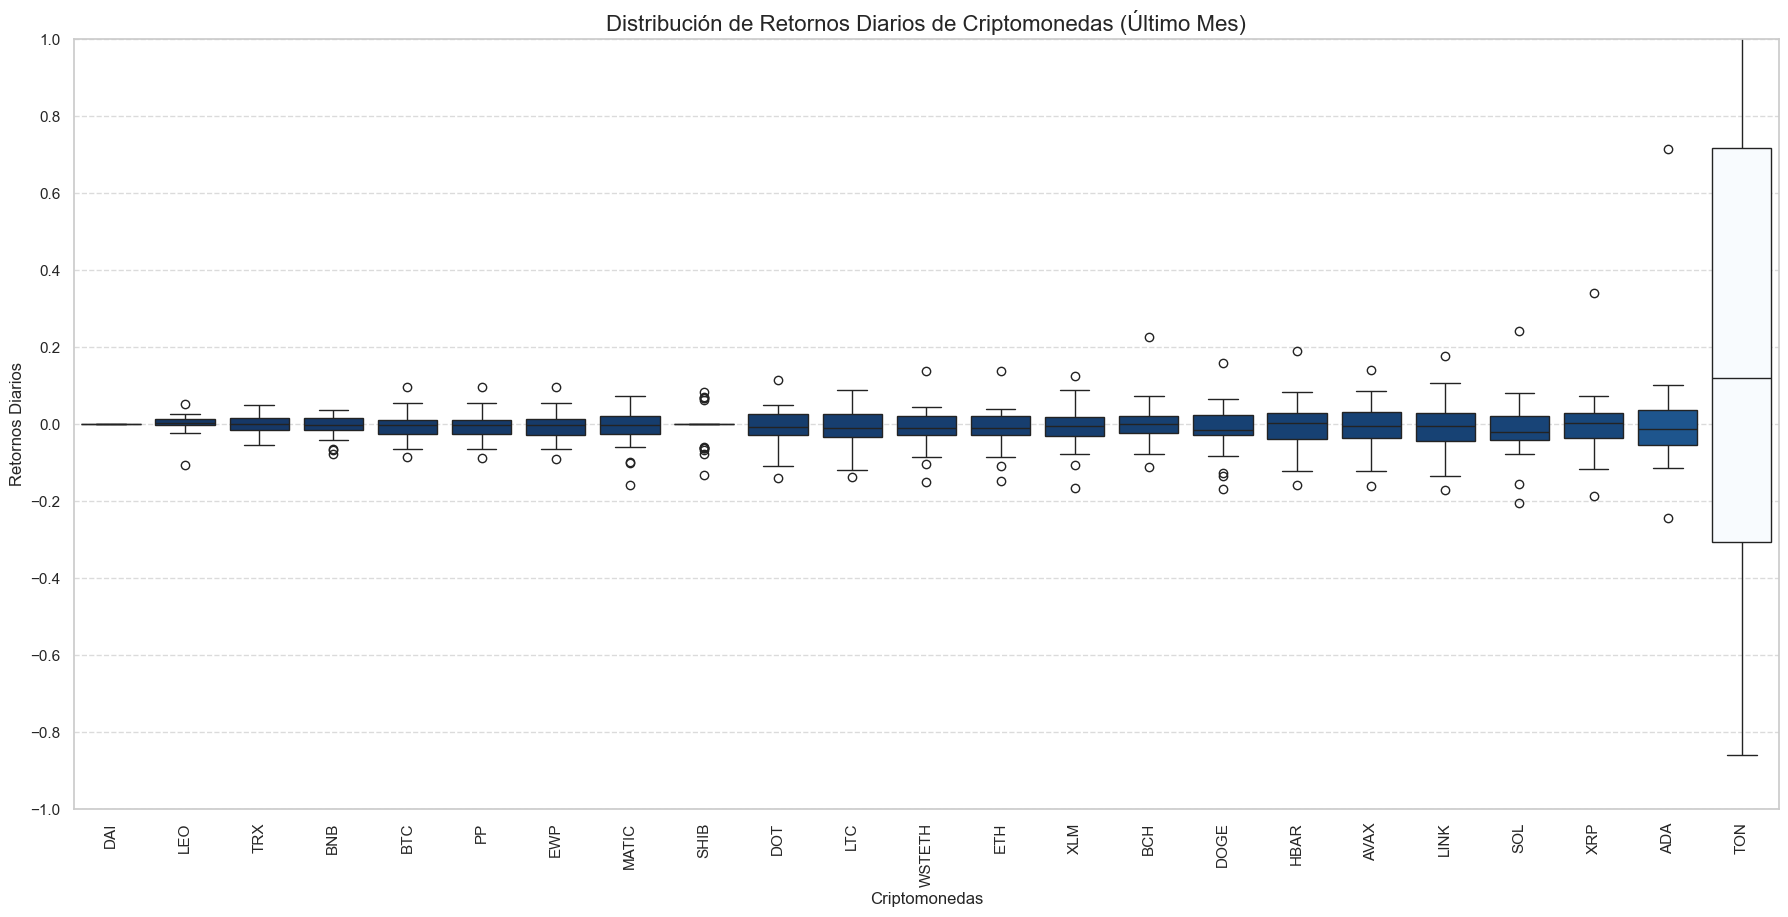

In [19]:

returns = data.pct_change().dropna()            # Calculate returns

# keep from the last 2 years
returns = returns['2025-02-14':]

returns_std = returns.std().sort_values().index # order them by the standard deviation
returns = returns[returns_std]                  # change the order of the columns

# Calculate the variance of returns
returns_std = returns.std()

# Create a color palette based on the variance
cmap = sns.color_palette("Blues_r", as_cmap=True)
colors = [cmap(v) for v in (returns_std - returns_std.min()) / (returns_std.max() - returns_std.min())]

# Adjust the figure size
fig, ax = plt.subplots(figsize=(22, 10))
sns.set(style='whitegrid')  # Set the style of
# Invert the color bar axis
cbar.ax.invert_yaxis()

# Remove the dark lines from the color bar
cbar.outline.set_edgecolor('none')


# Create the boxplot
sns.boxplot(data=returns, ax=ax, palette=colors)

# Customize the plot
plt.title('Distribución de Retornos Diarios de Criptomonedas (Último Mes)', fontsize=16)
plt.xlabel('Criptomonedas', fontsize=12)
plt.ylabel('Retornos Diarios', fontsize=12)
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability

# add more lines in the y-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)
# Adjust the y-axis ticks to be at intervals of 0.5
ax.yaxis.set_major_locator(plt.MultipleLocator(0.2))
# Set the y-axis limits
ax.set_ylim(-1, 1)


# Save the figure as a pickle file
fig = plt.gcf()  # Get the current figure
import pickle
with open("pkl/05-bp1m.pkl", "wb") as f:
    pickle.dump(fig, f)


# Save the figure as SVG
plt.savefig('svg/05-cryptos-boxplot-1m.svg', format='svg', bbox_inches='tight')  # bbox_inches='tight' ensures everything is saved


plt.show()


C:\Users\herie\AppData\Local\Temp\ipykernel_2656\439999116.py:49: DeprecationWarning: Pickle, copy, and deepcopy support will be removed from itertools in Python 3.14.
  pickle.dump(fig, f)


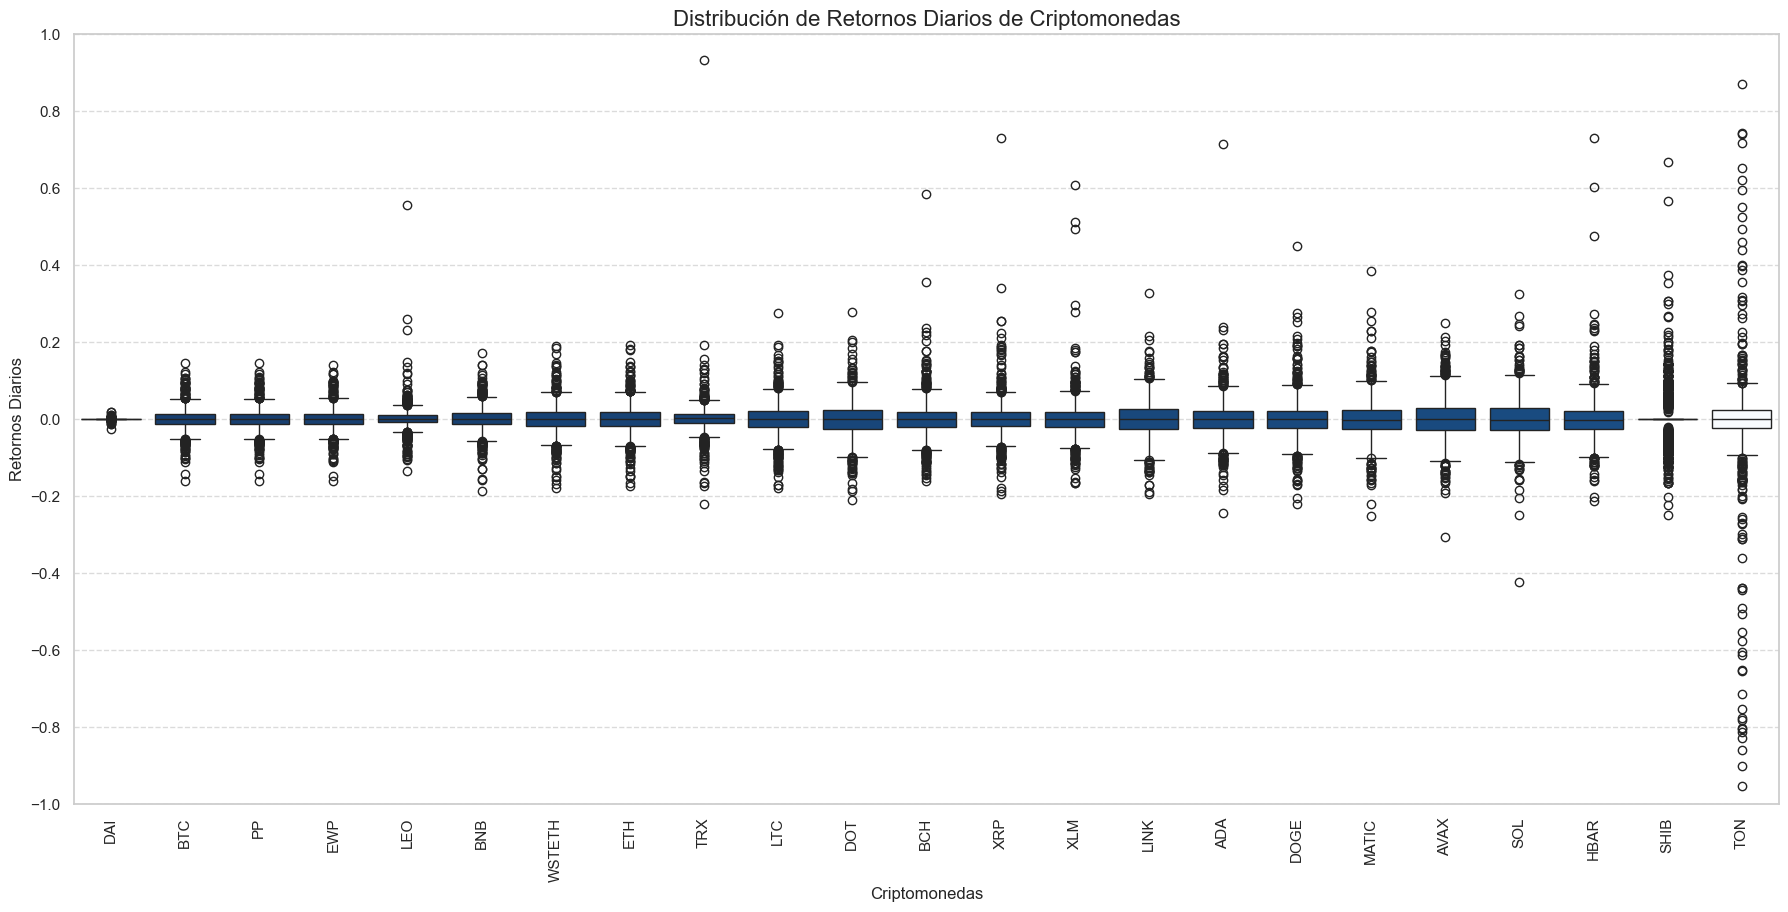

In [15]:

returns = data.pct_change().dropna()            # Calculate returns

returns_std = returns.std().sort_values().index # order them by the standard deviation
returns = returns[returns_std]                  # change the order of the columns

# Calculate the variance of returns
returns_std = returns.std()

# Create a color palette based on the variance
cmap = sns.color_palette("Blues_r", as_cmap=True)
colors = [cmap(v) for v in (returns_std - returns_std.min()) / (returns_std.max() - returns_std.min())]

# Adjust the figure size
fig, ax = plt.subplots(figsize=(22, 10))
sns.set(style='whitegrid')  # Set the style of
# Invert the color bar axis
cbar.ax.invert_yaxis()

# Remove the dark lines from the color bar
cbar.outline.set_edgecolor('none')


# Create the boxplot
sns.boxplot(data=returns, ax=ax, palette=colors)

# Customize the plot
plt.title('Distribución de Retornos Diarios de Criptomonedas', fontsize=16)
plt.xlabel('Criptomonedas', fontsize=12)
plt.ylabel('Retornos Diarios', fontsize=12)
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability

# add more lines in the y-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)
# Adjust the y-axis ticks to be at intervals of 0.5
ax.yaxis.set_major_locator(plt.MultipleLocator(0.2))
# Set the y-axis limits
ax.set_ylim(-1, 1)



# Save the figure as SVG
plt.savefig('svg/05-cryptos-boxplot.svg', format='svg', bbox_inches='tight')  # bbox_inches='tight' ensures everything is saved


# Save the figure as a pickle file
fig = plt.gcf()  # Get the current figure
import pickle
with open("pkl/05-bp.pkl", "wb") as f:
    pickle.dump(fig, f)


plt.show()
